<a href="https://www.kaggle.com/code/sonawanelalitsunil/discipline-report-card-2022-23-ml-100?scriptVersionId=264264656" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/report-card-discipline-for-2022-23/Report_Card_Discipline_for_2022-23.csv


## Title :
📊 Discipline Report Card 2022–23

## Description:
The Discipline Report Card 2022–23 provides a comprehensive overview of school-level discipline data across districts and counties. It highlights patterns in disciplinary actions, student behavior, and organizational practices, enabling stakeholders to evaluate trends and identify areas for improvement. This dataset serves as a valuable resource for educators, administrators, and policymakers to promote accountability, transparency, and positive student outcomes.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/report-card-discipline-for-2022-23/Report_Card_Discipline_for_2022-23.csv")

In [3]:
df.head()

,SchoolYear,OrganizationLevel,County,ESDName,ESDOrganizationId,DistrictCode,DistrictName,DistrictOrganizationId,SchoolCode,SchoolName,...,RateExcluded1DayOrLess,Excluded2To3Days,RateExcluded2To3Days,Excluded4To5Days,RateExcluded4To5Days,Excluded6To10Days,RateExcluded6To10Days,Excluded10DaysOrMore,RateExcluded10DaysOrMore,DateExtracted
0,2022-23,School,Pierce,Puget Sound Educational Service District 121,100006.0,27400.0,Clover Park School District,100047.0,5027.0,General William H. Harrison Preparatory School,...,33.33%,4,44.44%,2,22.22%,0,0.00%,0,0.00%,2024-01-21T08:29:06.290Z
1,2022-23,School,Pierce,Puget Sound Educational Service District 121,100006.0,27400.0,Clover Park School District,100047.0,5027.0,General William H. Harrison Preparatory School,...,0.00%,3,100.00%,0,0.00%,0,0.00%,0,0.00%,2024-01-21T08:29:06.290Z
2,2022-23,School,Pierce,Puget Sound Educational Service District 121,100006.0,27400.0,Clover Park School District,100047.0,5027.0,General William H. Harrison Preparatory School,...,Top/Bottom Range,*,Top/Bottom Range,*,Top/Bottom Range,*,Top/Bottom Range,*,Top/Bottom Range,2024-01-21T08:29:06.290Z
3,2022-23,School,Pierce,Puget Sound Educational Service District 121,100006.0,27400.0,Clover Park School District,100047.0,5027.0,General William H. Harrison Preparatory School,...,6.67%,12,80.00%,1,6.67%,0,0.00%,1,6.67%,2024-01-21T08:29:06.290Z
4,2022-23,School,Pierce,Puget Sound Educational Service District 121,100006.0,27400.0,Clover Park School District,100047.0,5027.0,General William H. Harrison Preparatory School,...,6.25%,9,56.25%,4,25.00%,2,12.50%,0,0.00%,2024-01-21T08:29:06.290Z


In [4]:
df.tail()

,SchoolYear,OrganizationLevel,County,ESDName,ESDOrganizationId,DistrictCode,DistrictName,DistrictOrganizationId,SchoolCode,SchoolName,...,RateExcluded1DayOrLess,Excluded2To3Days,RateExcluded2To3Days,Excluded4To5Days,RateExcluded4To5Days,Excluded6To10Days,RateExcluded6To10Days,Excluded10DaysOrMore,RateExcluded10DaysOrMore,DateExtracted
454050,2022-23,School,Yakima,Educational Service District 105,100002.0,39205.0,Zillah School District,100305.0,4481.0,Zillah Middle School,...,Top/Bottom Range,*,Top/Bottom Range,*,Top/Bottom Range,*,Top/Bottom Range,*,Top/Bottom Range,2024-01-21T08:29:06.290Z
454051,2022-23,School,Yakima,Educational Service District 105,100002.0,39205.0,Zillah School District,100305.0,4481.0,Zillah Middle School,...,Top/Bottom Range,*,Top/Bottom Range,*,Top/Bottom Range,*,Top/Bottom Range,*,Top/Bottom Range,2024-01-21T08:29:06.290Z
454052,2022-23,School,Yakima,Educational Service District 105,100002.0,39205.0,Zillah School District,100305.0,4481.0,Zillah Middle School,...,Top/Bottom Range,*,Top/Bottom Range,*,Top/Bottom Range,*,Top/Bottom Range,*,Top/Bottom Range,2024-01-21T08:29:06.290Z
454053,2022-23,School,Yakima,Educational Service District 105,100002.0,39205.0,Zillah School District,100305.0,4481.0,Zillah Middle School,...,0.00%,1,33.33%,0,0.00%,2,66.67%,0,0.00%,2024-01-21T08:29:06.290Z
454054,2022-23,School,Yakima,Educational Service District 105,100002.0,39205.0,Zillah School District,100305.0,4481.0,Zillah Middle School,...,0.00%,1,20.00%,0,0.00%,3,60.00%,1,20.00%,2024-01-21T08:29:06.290Z


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 454055 entries, 0 to 454054
Data columns (total 29 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   SchoolYear                454055 non-null  object 
 1   OrganizationLevel         454055 non-null  object 
 2   County                    454055 non-null  object 
 3   ESDName                   443633 non-null  object 
 4   ESDOrganizationId         443227 non-null  float64
 5   DistrictCode              453649 non-null  float64
 6   DistrictName              454055 non-null  object 
 7   DistrictOrganizationId    453649 non-null  float64
 8   SchoolCode                354129 non-null  float64
 9   SchoolName                454055 non-null  object 
 10  SchoolOrganizationId      354129 non-null  float64
 11  CurrentSchoolType         354129 non-null  object 
 12  Student Group             454055 non-null  object 
 13  GradeLevel                454055 non-null  o

In [6]:
df.describe()

,ESDOrganizationId,DistrictCode,DistrictOrganizationId,SchoolCode,SchoolOrganizationId
count,443227.000000,453649.000000,453649.00000,354129.000000,354129.000000
mean,100066.988209,22176.543414,100267.66644,3596.478710,102619.952441
std,595.489618,10390.662122,800.68108,1149.646042,1759.407978
min,100001.000000,1109.000000,100001.00000,1502.000000,100326.000000
25%,100003.000000,17001.000000,100083.00000,2701.000000,101336.000000
50%,100006.000000,21237.000000,100159.00000,3446.000000,102256.000000
75%,100007.000000,31103.000000,100233.00000,4417.000000,103142.000000
max,105886.000000,39801.000000,106989.00000,5961.000000,106992.000000


In [7]:
df.nunique()

SchoolYear                     1
OrganizationLevel              3
County                        40
ESDName                       12
ESDOrganizationId             11
DistrictCode                 331
DistrictName                 332
DistrictOrganizationId       331
SchoolCode                  2419
SchoolName                  2255
SchoolOrganizationId        2419
CurrentSchoolType              9
Student Group                 29
GradeLevel                    14
DisciplineDATNotes             5
DisciplineDenominator       4935
DisciplineNumerator          787
DisciplineRate              4819
Excluded1DayOrLess           435
RateExcluded1DayOrLess      3200
Excluded2To3Days             471
RateExcluded2To3Days        2812
Excluded4To5Days             291
RateExcluded4To5Days        2284
Excluded6To10Days            285
RateExcluded6To10Days       2281
Excluded10DaysOrMore         264
RateExcluded10DaysOrMore    2440
DateExtracted                  1
dtype: int64

In [8]:
df.isnull().sum()

SchoolYear                      0
OrganizationLevel               0
County                          0
ESDName                     10422
ESDOrganizationId           10828
DistrictCode                  406
DistrictName                    0
DistrictOrganizationId        406
SchoolCode                  99926
SchoolName                      0
SchoolOrganizationId        99926
CurrentSchoolType           99926
Student Group                   0
GradeLevel                      0
DisciplineDATNotes          53161
DisciplineDenominator           0
DisciplineNumerator             0
DisciplineRate               3087
Excluded1DayOrLess              0
RateExcluded1DayOrLess       3087
Excluded2To3Days                0
RateExcluded2To3Days         3087
Excluded4To5Days                0
RateExcluded4To5Days         3087
Excluded6To10Days               0
RateExcluded6To10Days        3087
Excluded10DaysOrMore            0
RateExcluded10DaysOrMore     3087
DateExtracted                   0
dtype: int64

In [9]:
df.duplicated().sum()

28

In [10]:
df.dtypes

SchoolYear                   object
OrganizationLevel            object
County                       object
ESDName                      object
ESDOrganizationId           float64
DistrictCode                float64
DistrictName                 object
DistrictOrganizationId      float64
SchoolCode                  float64
SchoolName                   object
SchoolOrganizationId        float64
CurrentSchoolType            object
Student Group                object
GradeLevel                   object
DisciplineDATNotes           object
DisciplineDenominator        object
DisciplineNumerator          object
DisciplineRate               object
Excluded1DayOrLess           object
RateExcluded1DayOrLess       object
Excluded2To3Days             object
RateExcluded2To3Days         object
Excluded4To5Days             object
RateExcluded4To5Days         object
Excluded6To10Days            object
RateExcluded6To10Days        object
Excluded10DaysOrMore         object
RateExcluded10DaysOrMore    

In [11]:
df.shape

(454055, 29)

In [12]:
df.columns

Index(['SchoolYear', 'OrganizationLevel', 'County', 'ESDName',
       'ESDOrganizationId', 'DistrictCode', 'DistrictName',
       'DistrictOrganizationId', 'SchoolCode', 'SchoolName',
       'SchoolOrganizationId', 'CurrentSchoolType', 'Student Group',
       'GradeLevel', 'DisciplineDATNotes', 'DisciplineDenominator',
       'DisciplineNumerator', 'DisciplineRate', 'Excluded1DayOrLess',
       'RateExcluded1DayOrLess', 'Excluded2To3Days', 'RateExcluded2To3Days',
       'Excluded4To5Days', 'RateExcluded4To5Days', 'Excluded6To10Days',
       'RateExcluded6To10Days', 'Excluded10DaysOrMore',
       'RateExcluded10DaysOrMore', 'DateExtracted'],
      dtype='object')

## Data visualizations

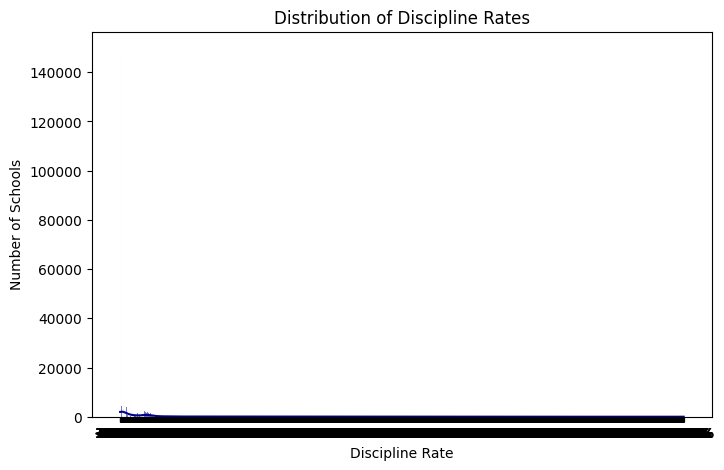

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df['DisciplineRate'], bins=30, kde=True, color='darkblue')
plt.title("Distribution of Discipline Rates")
plt.xlabel("Discipline Rate")
plt.ylabel("Number of Schools")
plt.show()

## ML Algorithms 

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [15]:
# Drop ID-like columns
drop_cols = ['SchoolCode','SchoolOrganizationId','DistrictCode','DistrictOrganizationId',
             'ESDOrganizationId','DateExtracted','DisciplineDATNotes']
df = df.drop(columns=drop_cols, errors='ignore')

In [16]:
print("After dropping ID cols:", df.shape)

After dropping ID cols: (454055, 22)


In [17]:
# Fill missing values
df = df.fillna("Unknown")

# Encode categorical columns
cat_cols = df.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [18]:
print("After encoding:", df.shape)

After encoding: (454055, 22)


In [19]:
# Ensure DisciplineRate exists and is numeric
if "DisciplineRate" not in df.columns:
    raise ValueError("❌ DisciplineRate column not found in dataset!")

df['DisciplineRate'] = pd.to_numeric(df['DisciplineRate'], errors='coerce')
df = df.dropna(subset=['DisciplineRate'])

In [20]:
# Create binary target
target = "DisciplineRateClass"
median_rate = df['DisciplineRate'].median()
df[target] = np.where(df['DisciplineRate'] > median_rate, 1, 0)

X = df.drop(columns=[target])
y = df[target]

In [21]:
print("Features shape:", X.shape, "| Target shape:", y.shape)

Features shape: (454055, 22) | Target shape: (454055,)


In [22]:
if len(X) == 0:
    raise ValueError("❌ No data left after preprocessing. Check your input CSV.")

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [23]:
# Train models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Gradient Boosting": GradientBoostingClassifier()
}

results = {}

for name, model in models.items():
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred) * 100
        results[name] = acc
        print(f"{name}: {acc:.2f}%")
    except Exception as e:
        print(f"{name} failed: {e}")


Logistic Regression: 69.49%
Decision Tree: 100.00%
Random Forest: 100.00%
KNN: 99.15%
SVM: 98.10%
Gradient Boosting: 100.00%


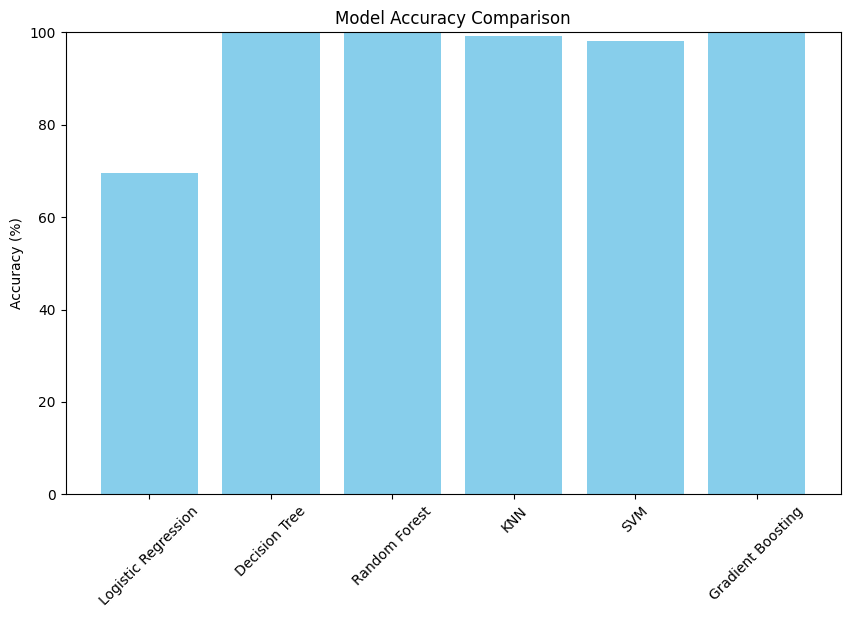

In [24]:
if results:
    plt.figure(figsize=(10,6))
    plt.bar(results.keys(), results.values(), color='skyblue')
    plt.ylabel("Accuracy (%)")
    plt.title("Model Accuracy Comparison")
    plt.xticks(rotation=45)
    plt.ylim(0, 100)
    plt.show()